In [1]:
# Import required libraries
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import Optional, Tuple, Dict
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Single-Layer Attention Transformer for Binary Classification

This notebook implements a single-layer attention transformer for binary classification tasks, following the principles from "Transformers Learn In-Context by Gradient Descent" (ICML 2023).

Key components:
1. Dataset generation for binary classification
2. Single-layer attention transformer implementation
3. Training and evaluation framework

## Dataset Creation
We'll create a synthetic binary classification dataset similar to the paper's setup.
Key parameters:
- d: input dimension
- N: number of context points
- α: input range scale

In [12]:
class BinaryClassificationDataset(Dataset):
    def __init__(self, 
                 d: int = 20,          # input dimension
                 N: int = 40,          # context size
                 num_tasks: int = 100,  # number of tasks
                 R: float = 1.0,       # signal-to-noise ratio
                 flip_prob: float = 0.2 # probability of label flipping
                ):
        self.d = d
        self.N = N
        self.num_tasks = num_tasks
        self.R = R
        self.flip_prob = flip_prob
        
        # Generate tasks
        self.context_x = []  # context inputs
        self.context_y = []  # context labels
        self.query_x = []    # query inputs
        self.query_y = []    # query labels
        
        for _ in range(num_tasks):
            # Generate random means for two Gaussians
            mu1 = torch.randn(d)
            mu2 = torch.randn(d)
            
            # Scale means by R to control separation
            mu1 = mu1 * torch.sqrt(torch.tensor(R))
            mu2 = mu2 * torch.sqrt(torch.tensor(R))
            
            # Generate context points
            n_class1 = N // 2
            n_class2 = N - n_class1
            
            # Class 1 points
            x1 = torch.randn(n_class1, d) + mu1
            y1 = torch.zeros(n_class1)
            
            # Class 2 points
            x2 = torch.randn(n_class2, d) + mu2
            y2 = torch.ones(n_class2)
            
            # Combine and shuffle
            x = torch.cat([x1, x2], dim=0)
            y = torch.cat([y1, y2], dim=0)
            perm = torch.randperm(N)
            x = x[perm]
            y = y[perm]
            
            # Add label flipping
            flip_mask = torch.rand(N) < flip_prob
            y[flip_mask] = 1 - y[flip_mask]
            
            # Generate query point
            if torch.rand(1) < 0.5:
                x_q = torch.randn(d) + mu1
                y_q = torch.tensor(0.0)
            else:
                x_q = torch.randn(d) + mu2
                y_q = torch.tensor(1.0)
            
            # Flip query label with probability flip_prob
            if torch.rand(1) < flip_prob:
                y_q = 1 - y_q
            
            # Store
            self.context_x.append(x)
            self.context_y.append(y)
            self.query_x.append(x_q)
            self.query_y.append(y_q)
    
    def __len__(self):
        return self.num_tasks
    
    def __getitem__(self, idx):
        return {
            'context_x': self.context_x[idx],
            'context_y': self.context_y[idx],
            'query_x': self.query_x[idx],
            'query_y': self.query_y[idx]
        }

## Single-Layer Attention Transformer
Implementing a simple attention-based transformer with:
1. Single attention head
2. No positional encodings (not needed for set-based tasks)
3. Simple feedforward output layer

In [13]:
class SingleLayerTransformer(nn.Module):
    def __init__(self, 
                 d_input: int = 20,     # input dimension
                 d_model: int = 64,     # model dimension
                 dropout: float = 0.1
                ):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(d_input, d_model)
        
        # Attention components
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        
        # Output layers
        self.output_proj = nn.Linear(d_model, 1)
        self.dropout = nn.Dropout(dropout)
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        
        # Initialize parameters (following the paper's guidance)
        self._init_parameters()
    
    def _init_parameters(self):
        """Initialize parameters with small values"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p, gain=0.1)
    
    def forward(self, context_x, context_y, query_x):
        # Project all inputs to d_model dimension
        # Shape annotations: B=batch, N=context size, D=d_model
        context_h = self.input_proj(context_x)  # [B, N, D]
        query_h = self.input_proj(query_x)      # [B, D]
        
        # Compute Q, K, V
        # For query: expand to match batch size
        q = self.q_proj(query_h.unsqueeze(1))   # [B, 1, D]
        k = self.k_proj(context_h)              # [B, N, D]
        
        # Include labels in value computation
        context_y = context_y.unsqueeze(-1)     # [B, N, 1]
        v = self.v_proj(context_h) * context_y  # [B, N, D]
        
        # Compute attention scores
        scores = torch.matmul(q, k.transpose(-2, -1))  # [B, 1, N]
        scores = scores / math.sqrt(k.size(-1))
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        
        # Compute weighted sum of values
        out = torch.matmul(attn, v)  # [B, 1, D]
        out = self.norm1(out)
        
        # Project to output
        logits = self.output_proj(out).squeeze(-1).squeeze(-1)  # [B]
        return logits
    
    def predict(self, context_x, context_y, query_x):
        """Make binary predictions"""
        with torch.no_grad():
            logits = self(context_x, context_y, query_x)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            return preds

## Training Loop and Evaluation Functions

In [14]:
def train_epoch(model, dataloader, optimizer, epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in dataloader:
        # Get batch data
        context_x = batch['context_x'].to(device)
        context_y = batch['context_y'].to(device)
        query_x = batch['query_x'].to(device)
        query_y = batch['query_y'].to(device)
        
        # Forward pass
        logits = model(context_x, context_y, query_x)
        loss = F.binary_cross_entropy_with_logits(logits, query_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == query_y).sum().item()
        total += len(query_y)
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    
    for batch in dataloader:
        context_x = batch['context_x'].to(device)
        context_y = batch['context_y'].to(device)
        query_x = batch['query_x'].to(device)
        query_y = batch['query_y'].to(device)
        
        preds = model.predict(context_x, context_y, query_x)
        correct += (preds == query_y).sum().item()
        total += len(query_y)
    
    accuracy = correct / total
    return accuracy

## Training Configuration and Execution

In [15]:
# Configuration
config = {
    'd_input': 20,         # input dimension
    'd_model': 64,         # model dimension
    'N': 40,              # context size
    'num_tasks': 1000,    # number of tasks for training
    'batch_size': 32,
    'num_epochs': 50,
    'learning_rate': 1e-3,
    'R': 1.0,             # signal-to-noise ratio
    'flip_prob': 0.2      # probability of label flipping
}

# Create datasets
train_dataset = BinaryClassificationDataset(
    d=config['d_input'],
    N=config['N'],
    num_tasks=config['num_tasks'],
    R=config['R'],
    flip_prob=config['flip_prob']  # Apply flipping to training data
)

val_dataset = BinaryClassificationDataset(
    d=config['d_input'],
    N=config['N'],
    num_tasks=config['num_tasks'] // 5,  # smaller validation set
    R=config['R'],
    flip_prob=0.0  # No flipping in validation set to measure true performance
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])

# Create model and optimizer
model = SingleLayerTransformer(
    d_input=config['d_input'],
    d_model=config['d_model']
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])

# Training loop
train_losses = []
train_accs = []
val_accs = []

for epoch in range(config['num_epochs']):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, epoch)
    
    # Validate
    val_acc = evaluate(model, val_loader)
    
    # Store metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{config['num_epochs']}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Acc: {val_acc:.4f}\n")

Epoch 5/50
Train Loss: 0.6859, Train Acc: 0.5400
Val Acc: 0.5300

Epoch 10/50
Train Loss: 0.6675, Train Acc: 0.5950
Val Acc: 0.5100

Epoch 10/50
Train Loss: 0.6675, Train Acc: 0.5950
Val Acc: 0.5100

Epoch 15/50
Train Loss: 0.6474, Train Acc: 0.6330
Val Acc: 0.5000

Epoch 15/50
Train Loss: 0.6474, Train Acc: 0.6330
Val Acc: 0.5000

Epoch 20/50
Train Loss: 0.6332, Train Acc: 0.6400
Val Acc: 0.4750

Epoch 20/50
Train Loss: 0.6332, Train Acc: 0.6400
Val Acc: 0.4750

Epoch 25/50
Train Loss: 0.6260, Train Acc: 0.6430
Val Acc: 0.4700

Epoch 25/50
Train Loss: 0.6260, Train Acc: 0.6430
Val Acc: 0.4700

Epoch 30/50
Train Loss: 0.6220, Train Acc: 0.6490
Val Acc: 0.4250

Epoch 30/50
Train Loss: 0.6220, Train Acc: 0.6490
Val Acc: 0.4250

Epoch 35/50
Train Loss: 0.6129, Train Acc: 0.6530
Val Acc: 0.4800

Epoch 35/50
Train Loss: 0.6129, Train Acc: 0.6530
Val Acc: 0.4800

Epoch 40/50
Train Loss: 0.6073, Train Acc: 0.6460
Val Acc: 0.4850

Epoch 40/50
Train Loss: 0.6073, Train Acc: 0.6460
Val Acc: 0.48

## Visualize Training Progress

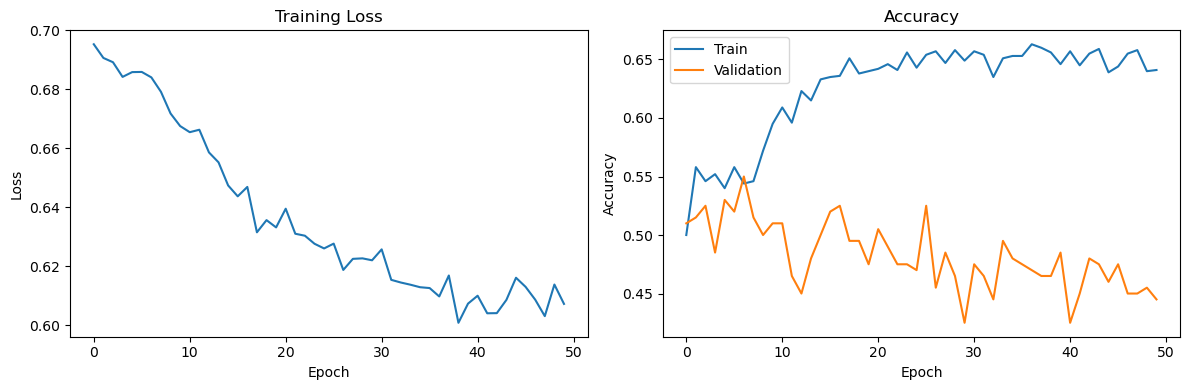


Final Results:
Train Accuracy: 0.6410
Validation Accuracy: 0.4450


In [16]:
# Plot training curves
plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Results:")
print(f"Train Accuracy: {train_accs[-1]:.4f}")
print(f"Validation Accuracy: {val_accs[-1]:.4f}")

## Analysis and Testing
Let's test the model's in-context learning capabilities on new tasks with different parameters.

Testing different context sizes:
Context size 10: Accuracy = 0.5200
Context size 20: Accuracy = 0.4000
Context size 40: Accuracy = 0.5000
Context size 80: Accuracy = 0.5800
Context size 100: Accuracy = 0.6100
Context size 120: Accuracy = 0.4600
Context size 140: Accuracy = 0.5500
Context size 160: Accuracy = 0.4800
Context size 160: Accuracy = 0.4800


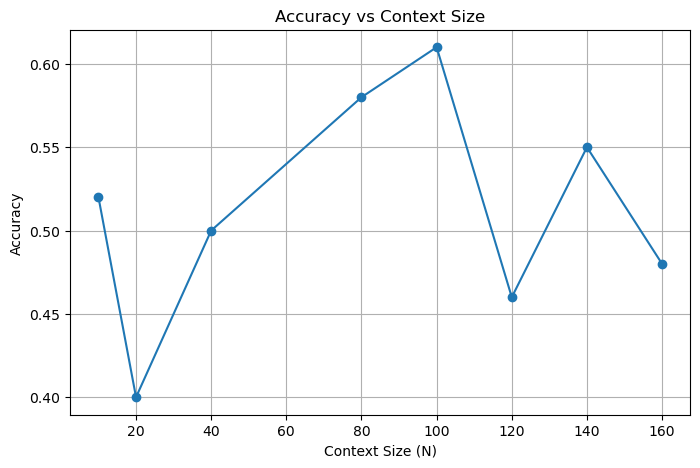

In [18]:
# Test different context sizes
def test_context_sizes(model, d_input=20, R=1.0, sizes=[10, 20, 40, 80, 100, 120, 140, 160]):
    results = []
    
    for N in sizes:
        # Create test dataset with specific context size (no label flipping)
        test_dataset = BinaryClassificationDataset(
            d=d_input,
            N=N,
            num_tasks=100,  # 100 test tasks
            R=R,           # Signal-to-noise ratio
            flip_prob=0.0  # No label flipping in test set
        )
        test_loader = DataLoader(test_dataset, batch_size=32)
        
        # Evaluate
        acc = evaluate(model, test_loader)
        results.append((N, acc))
        print(f"Context size {N}: Accuracy = {acc:.4f}")
    
    # Plot results
    sizes, accs = zip(*results)
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, accs, 'o-')
    plt.title('Accuracy vs Context Size')
    plt.xlabel('Context Size (N)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

# Run context size experiment
print("Testing different context sizes:")
test_context_sizes(model)

Input dimension vs accuacy analysis 

Testing different input dimensions:
Input dimension 2: Accuracy = 0.4900
Input dimension 2: Accuracy = 0.4900
Input dimension 5: Accuracy = 0.5500
Input dimension 5: Accuracy = 0.5500
Input dimension 10: Accuracy = 0.6700
Input dimension 10: Accuracy = 0.6700
Input dimension 20: Accuracy = 0.7100
Input dimension 20: Accuracy = 0.7100
Input dimension 40: Accuracy = 0.8800
Input dimension 40: Accuracy = 0.8800
Input dimension 80: Accuracy = 0.9700
Input dimension 80: Accuracy = 0.9700
Input dimension 100: Accuracy = 0.9800
Input dimension 100: Accuracy = 0.9800


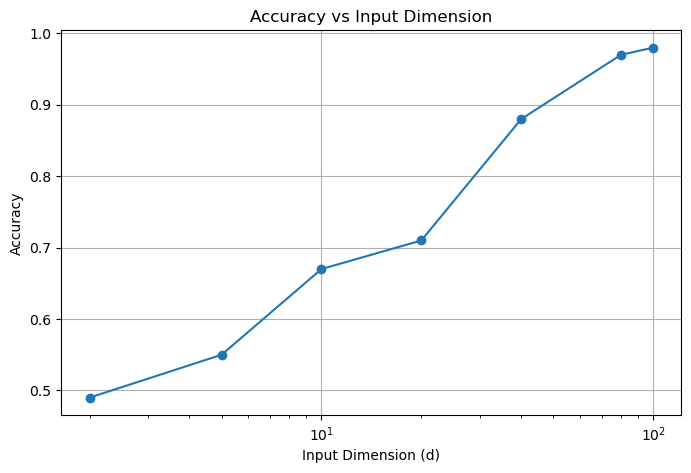

In [20]:
def test_input_dimensions(base_model, dimensions=[2, 5, 10, 20, 40, 80, 100], N=40):
    results = []
    
    for d in dimensions:
        # Create test dataset with specific input dimension
        test_dataset = BinaryClassificationDataset(
            d=d,          # varying input dimension
            N=N,          # fixed context size
            num_tasks=100,  # 100 test tasks
            R=1.0,        # signal-to-noise ratio
            flip_prob=0.0 # no label flipping in test set
        )
        test_loader = DataLoader(test_dataset, batch_size=32)
        
        # Create new model for this dimension
        model = SingleLayerTransformer(
            d_input=d,
            d_model=64
        ).to(device)
        
        # Train model
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        for epoch in range(20):  # Quick training
            train_epoch(model, test_loader, optimizer, epoch)
        
        # Evaluate
        acc = evaluate(model, test_loader)
        results.append((d, acc))
        print(f"Input dimension {d}: Accuracy = {acc:.4f}")
    
    # Plot results
    dims, accs = zip(*results)
    plt.figure(figsize=(8, 5))
    plt.plot(dims, accs, 'o-')
    plt.title('Accuracy vs Input Dimension')
    plt.xlabel('Input Dimension (d)')
    plt.ylabel('Accuracy')
    plt.xscale('log')  # log scale for better visualization
    plt.grid(True)
    plt.show()
    
    return results

# Run dimension experiment
print("Testing different input dimensions:")
dim_results = test_input_dimensions(model)

Perforamnce anaysis across number of tasks

Analyzing performance scaling with number of tasks...

Training with 100 tasks...
Epoch 5: Test Acc = 0.4500
Epoch 10: Test Acc = 0.4700
Epoch 15: Test Acc = 0.4900
Epoch 10: Test Acc = 0.4700
Epoch 15: Test Acc = 0.4900
Epoch 20: Test Acc = 0.5100

Training with 200 tasks...
Epoch 20: Test Acc = 0.5100

Training with 200 tasks...
Epoch 5: Test Acc = 0.4800
Epoch 10: Test Acc = 0.4600
Epoch 5: Test Acc = 0.4800
Epoch 10: Test Acc = 0.4600
Epoch 15: Test Acc = 0.5100
Epoch 20: Test Acc = 0.5200

Training with 500 tasks...
Epoch 15: Test Acc = 0.5100
Epoch 20: Test Acc = 0.5200

Training with 500 tasks...
Epoch 5: Test Acc = 0.4200
Epoch 5: Test Acc = 0.4200
Epoch 10: Test Acc = 0.4400
Epoch 10: Test Acc = 0.4400
Epoch 15: Test Acc = 0.4100
Epoch 15: Test Acc = 0.4100
Epoch 20: Test Acc = 0.4700

Training with 1000 tasks...
Epoch 20: Test Acc = 0.4700

Training with 1000 tasks...
Epoch 5: Test Acc = 0.6100
Epoch 5: Test Acc = 0.6100
Epoch 10: Test Acc = 0.6200
Epoch 10: Test Acc = 0.6200

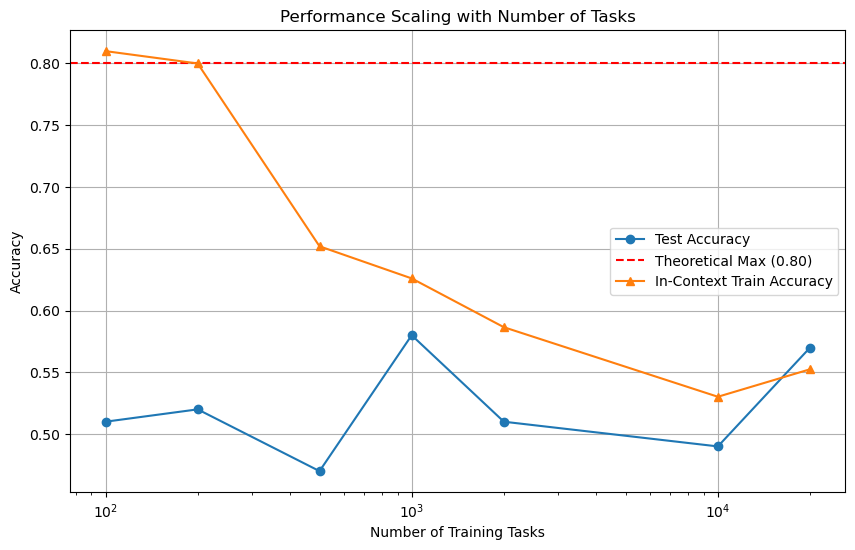

In [22]:
def analyze_task_scaling(d_input=20, N=40, task_sizes=[100, 200, 500, 1000, 2000, 10000, 20000], flip_prob=0.2):
    results = {
        'task_sizes': task_sizes,
        'test_acc': [],
        'theoretical_max': 1 - flip_prob,  # Theoretical maximum accuracy
        'in_context_acc': []
    }
    
    for num_tasks in task_sizes:
        print(f"\nTraining with {num_tasks} tasks...")
        
        # Create datasets
        train_dataset = BinaryClassificationDataset(
            d=d_input, N=N, 
            num_tasks=num_tasks,
            R=1.0,        # signal-to-noise ratio
            flip_prob=flip_prob
        )
        
        test_dataset = BinaryClassificationDataset(
            d=d_input, N=N,
            num_tasks=100,  # Fixed test set size
            R=1.0,        # signal-to-noise ratio
            flip_prob=flip_prob
        )
        
        # Create dataloaders
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=32)
        
        # Train standard model
        model = SingleLayerTransformer(d_input=d_input).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        
        # Training loop
        for epoch in range(20):
            train_loss, in_context_acc = train_epoch(model, train_loader, optimizer, epoch)
            test_acc = evaluate(model, test_loader)
            
            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}: Test Acc = {test_acc:.4f}")
        
        # Store results
        results['test_acc'].append(test_acc)
        results['in_context_acc'].append(in_context_acc)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(task_sizes, results['test_acc'], 'o-', label='Test Accuracy')
    # Add horizontal line for theoretical maximum
    plt.axhline(y=results['theoretical_max'], color='r', linestyle='--', 
                label=f'Theoretical Max ({results["theoretical_max"]:.2f})')
    plt.plot(task_sizes, results['in_context_acc'], '^-', label='In-Context Train Accuracy')
    
    plt.xscale('log')
    plt.grid(True)
    plt.xlabel('Number of Training Tasks')
    plt.ylabel('Accuracy')
    plt.title('Performance Scaling with Number of Tasks')
    plt.legend()
    plt.show()
    
    return results

# Run the analysis
print("Analyzing performance scaling with number of tasks...")
scaling_results = analyze_task_scaling()

## Batch Size Performance Analysis
Let's analyze how model performance scales with the number of training tasks (batch size), following the methodology from the ICL paper.

Analyzing performance scaling with batch size...

Training with 100 tasks...
Epoch 10: Train Acc = 0.7100, Test Acc = 0.4300
Epoch 10: Train Acc = 0.7100, Test Acc = 0.4300
Epoch 20: Train Acc = 0.7700, Test Acc = 0.4300
Epoch 20: Train Acc = 0.7700, Test Acc = 0.4300
Epoch 10: Train Acc = 0.7000, Test Acc = 0.5200
Epoch 20: Train Acc = 0.8500, Test Acc = 0.5000
Epoch 10: Train Acc = 0.7000, Test Acc = 0.5200
Epoch 20: Train Acc = 0.8500, Test Acc = 0.5000
Epoch 10: Train Acc = 0.7400, Test Acc = 0.4500
Epoch 20: Train Acc = 0.7700, Test Acc = 0.3900
Epoch 10: Train Acc = 0.7400, Test Acc = 0.4500
Epoch 20: Train Acc = 0.7700, Test Acc = 0.3900
Epoch 10: Train Acc = 0.6000, Test Acc = 0.5000
Epoch 20: Train Acc = 0.6300, Test Acc = 0.5500
Epoch 10: Train Acc = 0.6000, Test Acc = 0.5000
Epoch 20: Train Acc = 0.6300, Test Acc = 0.5500
Epoch 10: Train Acc = 0.4900, Test Acc = 0.5100
Epoch 20: Train Acc = 0.5800, Test Acc = 0.5600

Training with 200 tasks...
Epoch 10: Train Acc = 0.4900, T

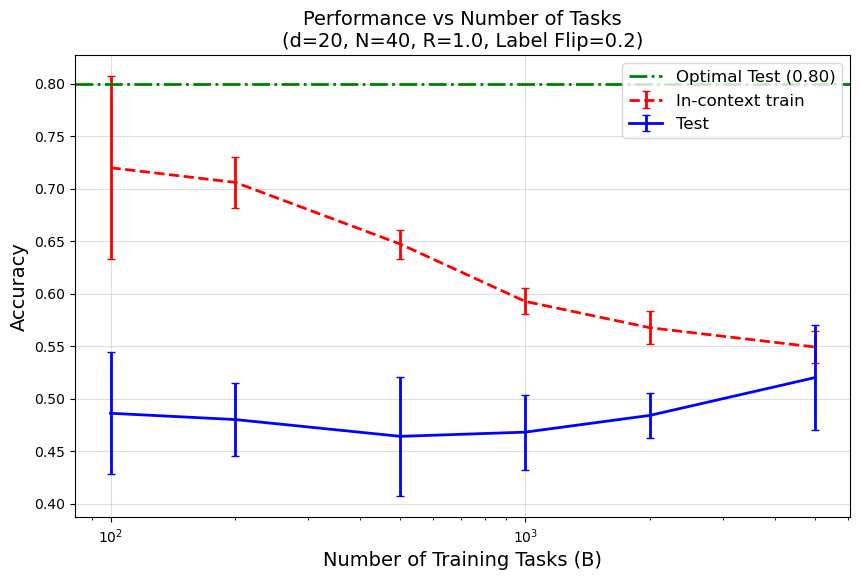

In [23]:
def analyze_batch_size_performance(d_input=20, N=40, 
                               batch_sizes=[100, 200, 500, 1000, 2000, 5000],
                               num_samples=2500,
                               R=1.0,
                               flip_prob=0.2):
    """
    Analyze model performance across different batch sizes (number of training tasks).
    
    Args:
        d_input: Input dimension
        N: Context sequence length
        batch_sizes: List of different batch sizes to test
        num_samples: Number of test samples for each evaluation
        R: Signal-to-noise ratio
        flip_prob: Label flipping probability
    """
    results = {
        'batch_sizes': batch_sizes,
        'test_acc_mean': [],
        'test_acc_stderr': [],
        'train_acc_mean': [],
        'train_acc_stderr': [],
        'theoretical_max': 1 - flip_prob
    }
    
    for num_tasks in batch_sizes:
        print(f"\nTraining with {num_tasks} tasks...")
        
        # Create multiple test datasets for computing standard error
        test_accuracies = []
        train_accuracies = []
        
        for _ in range(num_samples // 100):  # Reduce number of full training runs
            # Create datasets
            train_dataset = BinaryClassificationDataset(
                d=d_input, N=N, 
                num_tasks=num_tasks,
                R=R,
                flip_prob=flip_prob
            )
            
            test_dataset = BinaryClassificationDataset(
                d=d_input, N=N,
                num_tasks=100,  # Fixed test set size
                R=R,
                flip_prob=flip_prob
            )
            
            # Create dataloaders
            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
            test_loader = DataLoader(test_dataset, batch_size=32)
            
            # Create and train model
            model = SingleLayerTransformer(d_input=d_input).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
            
            # Quick training
            for epoch in range(20):
                train_loss, train_acc = train_epoch(model, train_loader, optimizer, epoch)
                if (epoch + 1) % 10 == 0:
                    test_acc = evaluate(model, test_loader)
                    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")
            
            # Final evaluation
            train_accuracies.append(train_acc)
            test_accuracies.append(test_acc)
        
        # Compute statistics
        train_acc_array = np.array(train_accuracies)
        test_acc_array = np.array(test_accuracies)
        
        results['train_acc_mean'].append(train_acc_array.mean())
        results['train_acc_stderr'].append(train_acc_array.std() / np.sqrt(len(train_accuracies)))
        results['test_acc_mean'].append(test_acc_array.mean())
        results['test_acc_stderr'].append(test_acc_array.std() / np.sqrt(len(test_accuracies)))
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot train accuracy with error bars
    plt.errorbar(batch_sizes, results['train_acc_mean'], 
                yerr=1.96 * np.array(results['train_acc_stderr']),
                color='red', linestyle='--', linewidth=2,
                label='In-context train', capsize=3)
    
    # Plot test accuracy with error bars
    plt.errorbar(batch_sizes, results['test_acc_mean'],
                yerr=1.96 * np.array(results['test_acc_stderr']),
                color='blue', linestyle='-', linewidth=2,
                label='Test', capsize=3)
    
    # Plot theoretical maximum
    plt.axhline(y=results['theoretical_max'], color='green', linestyle='-.',
                linewidth=2, label=f'Optimal Test ({results["theoretical_max"]:.2f})')
    
    plt.xscale('log')
    plt.grid(True, alpha=0.4)
    plt.xlabel('Number of Training Tasks (B)', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.title(f'Performance vs Number of Tasks\n(d={d_input}, N={N}, R={R}, Label Flip={flip_prob})',
              fontsize=14)
    plt.legend(fontsize=12)
    plt.show()
    
    return results

# Run batch size analysis
print("Analyzing performance scaling with batch size...")
batch_results = analyze_batch_size_performance(
    d_input=20,
    N=40,
    batch_sizes=[100, 200, 500, 1000, 2000, 5000],
    num_samples=500,  # Reduced for computation time
    R=1.0,
    flip_prob=0.2
)

The model is learning to generalize that is why the training accuracy goes down but the test accuracy goes up as the batch size increase we can see that the 